# Belief Activation on FinanceBench: PSRO baseline vs TGN-only

This notebook compares the two belief-activation engines on a real FinanceBench question:

- **PSRO baseline** (`engine="psro"`) — multi-agent population + Bayesian 2-hop imputation. The pre-TGN system.
- **TGN-only** (`engine="tgn_only"`) — a single Temporal Graph Network with a trained link-prediction head. No agents, no PSRO loop, no Bayesian prior.

Both engines see the **same** beliefs, the **same** NLI judge, and the **same** judge budget per batch. The only thing varying is the trainer.

**What we measure**
- Pair-resolution counts (judged vs imputed vs skipped) and edges committed.
- Latency (total wall time, mean and p95 step latency).
- Per-step training dynamics (loss, cumulative judges, cumulative edges).
- Held-out sign accuracy and MAE on uncommitted pairs, graded by NLI as ground truth.

**First-run cost**: this notebook downloads `MiniLM-L6-v2` (~80MB) for embeddings and `DeBERTa-v3-large-mnli-fever-anli-ling-wanli` (~180MB) for the NLI judge if they aren't already cached. Subsequent runs reuse the cached models.

In [1]:
%matplotlib inline
import asyncio
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from multi_agent.benchmarks import Batch
from multi_agent.config import MultiAgentConfig
from multi_agent.judge import NLIJudge
from multi_agent.runner import Trainer
from multi_agent.tgn_runner import TGNTrainer
from multi_agent.utils import run_sync, score_pairs
from multi_agent.utils.financebench import (
    load_financebench, make_financebench_batches, prose_questions,
)

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("torch", torch.__version__)

/Users/haripriyadhanasekaran/TGN_Belief_activation/belief_activation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.11.0


## 1. Load FinanceBench, pick a prose-heavy question

We default to the Verizon 2021 10-K question (44 beliefs after sentence-splitting) — it's the smallest of the prose-heavy corpus and runs fastest. Set `QID` to any other short id (e.g. `"01290"` Boeing or `"02416"` Pfizer) to run on a different question.

In [2]:
QID = "02024"

questions = load_financebench()
by_short = {q.short_id: q for q in questions}
if QID in by_short:
    question = by_short[QID]
else:
    question = prose_questions(questions, min_beliefs=15)[0]

print(f"Question: {question.short_id} \u2014 {question.company} {question.doc_period} {question.doc_type}")
print(f"  {question.question}")

Question: 02024 — Verizon 2021 10k
  As of FY 2021, how much did Verizon expect to pay for its retirees in 2024?


## 2. Build belief batches

Sentence-split the evidence pages, embed via MiniLM (cached on disk), chunk into 5 batches.

In [3]:
N_BATCHES = 5
EPOCHS = 2
JUDGE_BUDGET = 8

t0 = time.time()
batches = make_financebench_batches(question, n_batches=N_BATCHES, seed=SEED)
n_beliefs = sum(len(b.ids) for b in batches)
print(f"{n_beliefs} beliefs in {len(batches)} batches  ({time.time() - t0:.1f}s to build + embed)")

text_of: dict[str, str] = {}
for b in batches:
    text_of.update(dict(zip(b.ids, b.texts)))
for b in batches:
    print(f"  batch: {len(b.ids)} beliefs  (first text: '{b.texts[0][:80]}...')")

44 beliefs in 5 batches  (0.0s to build + embed)
  batch: 9 beliefs  (first text: 'Employee Benefit Plans Pension and postretirement health care and life insurance...')
  batch: 9 beliefs  (first text: 'For net investment hedges of certain of our foreign operations, the change in th...')
  batch: 9 beliefs  (first text: 'Cash flows from derivatives, which are designated as accounting hedges or applie...')
  batch: 9 beliefs  (first text: 'The charges were recorded in Other income (expense), net in our consolidated sta...')
  batch: 8 beliefs  (first text: 'Verizon management employees no longer earn pension benefits or earn service tow...')


## 3. Set up the NLI judge

One judge instance shared by both runs so judge calls are deterministic and the model is loaded only once.

In [4]:
print("Loading NLI judge (DeBERTa-v3-large-mnli) \u2014 first call may download ~180MB\u2026")
judge = NLIJudge()
print("  ready.")

Loading NLI judge (DeBERTa-v3-large-mnli) — first call may download ~180MB…
  ready.


## 4. Uniform run helper

Builds a `Trainer` (PSRO) or `TGNTrainer` (TGN-only) given the same config knobs. Records per-step stats and step latency for both.

In [5]:
def run_engine(engine: str, seed: int = SEED, epochs: int = EPOCHS) -> dict:
    """Run one full session under one engine. Returns metrics + per-step state."""
    np.random.seed(seed)
    torch.manual_seed(seed)

    config_engine = "tgn_only" if engine == "tgn_only" else "psro"
    cfg = MultiAgentConfig(
        emb_dim=batches[0].embs.shape[1],
        num_agents=3,
        k=8,
        seed=seed,
        agent_roles={
            "agent_0": "coherence",
            "agent_1": "contradiction",
            "cosine": "semantic",
        },
        judge_budget_per_batch=JUDGE_BUDGET,
        use_tgn=False,            # no BlendedImputer in this comparison
        engine=config_engine,
        tgn_memory_dim=64,
        tgn_time_dim=16,
        tgn_n_attn_heads=2,
    )
    trainer_cls = TGNTrainer if engine == "tgn_only" else Trainer
    trainer = trainer_cls(cfg, judge)

    per_step = []
    step_times_ms = []
    losses = []
    t_start = time.perf_counter()
    for _ in range(epochs):
        for batch in batches:
            t = time.perf_counter()
            res = trainer.step(batch)
            step_times_ms.append((time.perf_counter() - t) * 1000.0)
            per_step.append(res.stats)
            losses.append(float(res.stats.loss))
    total_s = time.perf_counter() - t_start

    # Held-out predictions for every uncommitted pair.
    edges = set(trainer.graph._edges.keys())
    nodes = trainer.graph.get_nodes()
    held_out = {}
    for i, q in enumerate(nodes):
        for c in nodes[i + 1 :]:
            if (q, c) in edges or (c, q) in edges:
                continue
            if engine == "tgn_only":
                held_out[(q, c)] = float(trainer.tgn.predict_link(q, c))
            else:
                held_out[(q, c)] = float(trainer.graph.field(q, c))

    return {
        "engine": engine,
        "per_step": per_step,
        "step_times_ms": step_times_ms,
        "losses": losses,
        "total_wall_time_s": total_s,
        "held_out": held_out,
        "n_committed_edges": len(trainer.graph._edges),
        "trainer": trainer,
    }

## 5. Run baseline (PSRO) and TGN-only

Both runs see the same batches, the same judge, the same budget.

In [6]:
print("Running baseline (PSRO)\u2026")
baseline = run_engine("baseline")
print(
    f"  done in {baseline['total_wall_time_s']:.2f}s, "
    f"{baseline['n_committed_edges']} edges committed, "
    f"{len(baseline['held_out'])} pairs held out"
)

print("\nRunning TGN-only\u2026")
tgn = run_engine("tgn_only")
print(
    f"  done in {tgn['total_wall_time_s']:.2f}s, "
    f"{tgn['n_committed_edges']} edges committed, "
    f"{len(tgn['held_out'])} pairs held out"
)

results = {"baseline": baseline, "tgn_only": tgn}
engines = ["baseline", "tgn_only"]
colors = {"baseline": "#4C78A8", "tgn_only": "#F58518"}

Running baseline (PSRO)…


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 9470.72it/s]

  done in 6.36s, 248 edges committed, 700 pairs held out

Running TGN-only…


  done in 2.39s, 40 edges committed, 906 pairs held out


## 6. Pair-resolution counts

How each engine spent its budget across the run. Lower **skipped** + higher **imputed** = more pairs resolved within the same judge budget.

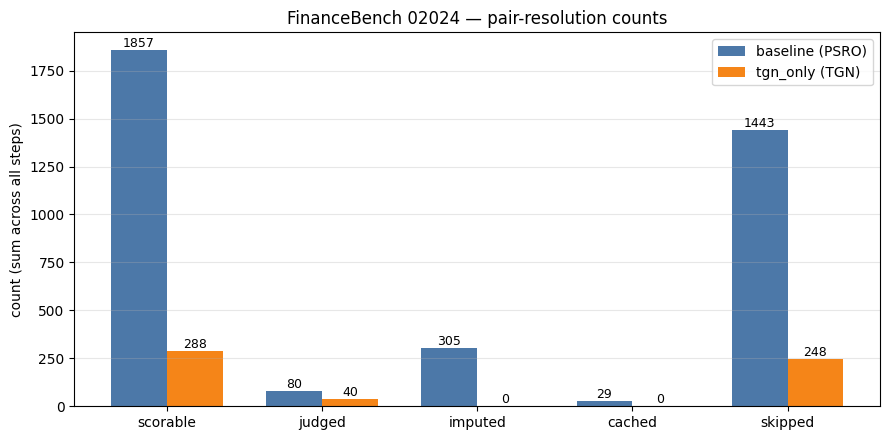

In [7]:
def total(stats, key):
    return sum(getattr(s, key) for s in stats)

metric_keys = ["scorable", "judged", "imputed", "cached", "skipped"]
data = {m: [total(results[e]["per_step"], m) for e in engines] for m in metric_keys}

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(metric_keys))
w = 0.36
ax.bar(x - w / 2, [data[m][0] for m in metric_keys], w, label="baseline (PSRO)", color=colors["baseline"])
ax.bar(x + w / 2, [data[m][1] for m in metric_keys], w, label="tgn_only (TGN)", color=colors["tgn_only"])
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylabel("count (sum across all steps)")
ax.set_title(f"FinanceBench {question.short_id} \u2014 pair-resolution counts")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, m in enumerate(metric_keys):
    for j in (0, 1):
        ax.annotate(
            f"{data[m][j]}",
            (x[i] + (j - 0.5) * w, data[m][j]),
            ha="center", va="bottom", fontsize=9,
        )
plt.tight_layout()
plt.show()

## 7. Latency comparison

Three views of speed: total wall time, mean per-step latency, and tail (p95) latency.

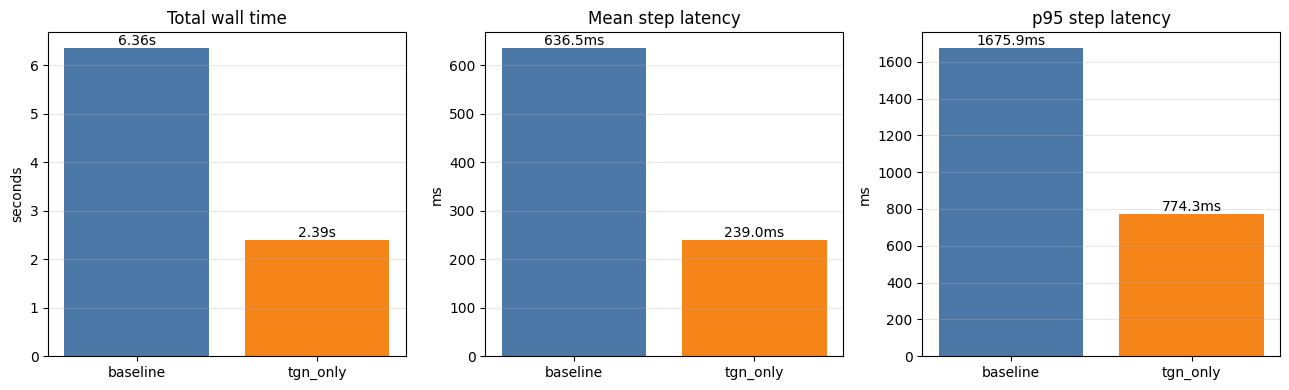

TGN-only is 2.66× faster than baseline on this question.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

walls = [results[e]["total_wall_time_s"] for e in engines]
axes[0].bar(engines, walls, color=[colors[e] for e in engines])
axes[0].set_title("Total wall time")
axes[0].set_ylabel("seconds")
for i, v in enumerate(walls):
    axes[0].annotate(f"{v:.2f}s", (i, v), ha="center", va="bottom")
axes[0].grid(axis="y", alpha=0.3)

mean_ms = [float(np.mean(results[e]["step_times_ms"])) for e in engines]
axes[1].bar(engines, mean_ms, color=[colors[e] for e in engines])
axes[1].set_title("Mean step latency")
axes[1].set_ylabel("ms")
for i, v in enumerate(mean_ms):
    axes[1].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[1].grid(axis="y", alpha=0.3)

p95_ms = [float(np.percentile(results[e]["step_times_ms"], 95)) for e in engines]
axes[2].bar(engines, p95_ms, color=[colors[e] for e in engines])
axes[2].set_title("p95 step latency")
axes[2].set_ylabel("ms")
for i, v in enumerate(p95_ms):
    axes[2].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

speedup = walls[0] / max(walls[1], 1e-9)
print(f"TGN-only is {speedup:.2f}\u00d7 faster than baseline on this question.")

## 8. Per-step dynamics

How each engine progresses through the stream of beliefs.

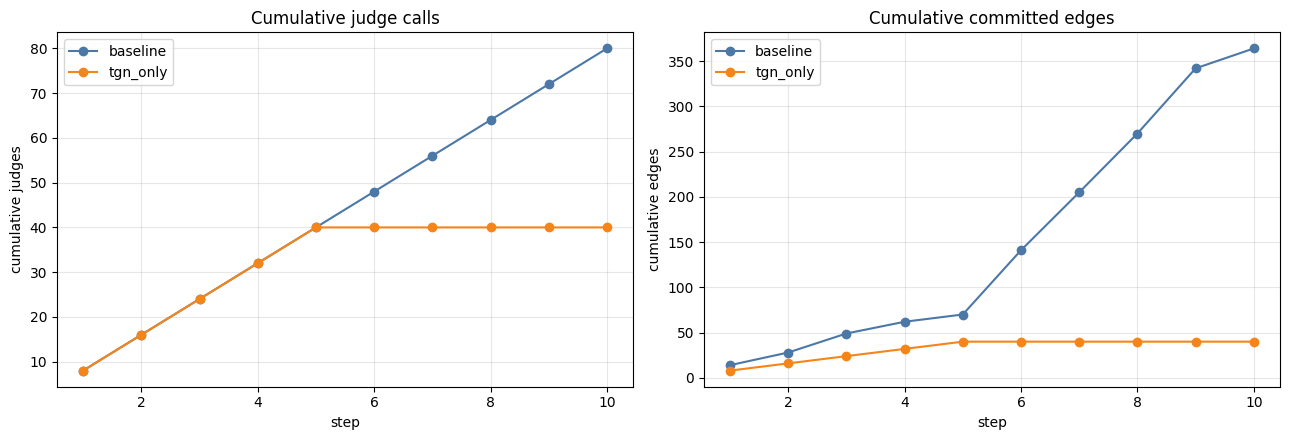

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for e in engines:
    stats = results[e]["per_step"]
    judged_cum = np.cumsum([s.judged for s in stats])
    edges_cum = np.cumsum([s.n_coh + s.n_dis for s in stats])
    xs = range(1, len(stats) + 1)
    axes[0].plot(xs, judged_cum, marker="o", color=colors[e], label=e)
    axes[1].plot(xs, edges_cum, marker="o", color=colors[e], label=e)

axes[0].set_title("Cumulative judge calls")
axes[0].set_xlabel("step")
axes[0].set_ylabel("cumulative judges")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Cumulative committed edges")
axes[1].set_xlabel("step")
axes[1].set_ylabel("cumulative edges")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Training loss

Different losses for different engines. **Baseline** reports `1 - mean reward` (REINFORCE objective). **TGN-only** reports MSE between `predict_link` and the judge's revealed `y`. The two are not directly comparable in absolute terms; observe direction only.

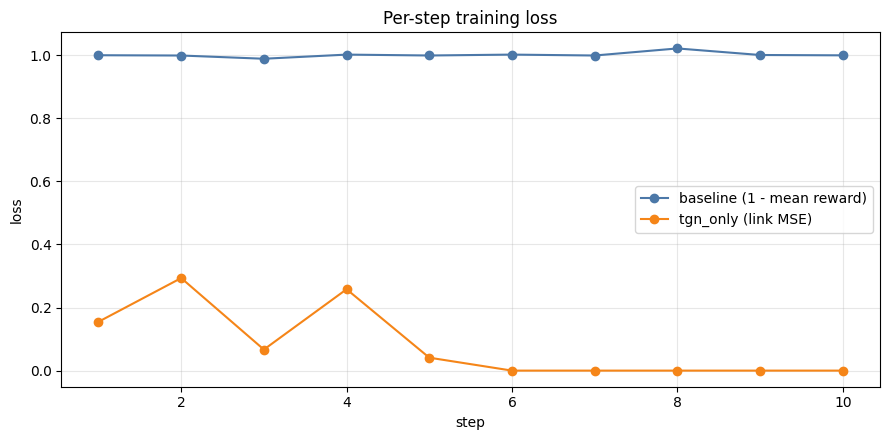

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for e, label in zip(
    engines, ["baseline (1 - mean reward)", "tgn_only (link MSE)"]
):
    losses = results[e]["losses"]
    ax.plot(range(1, len(losses) + 1), losses, marker="o",
            color=colors[e], label=label)

ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Per-step training loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 10. NLI-graded held-out evaluation

Both engines leave a different subset of pairs uncommitted. To compare quality fairly we score predictions only on pairs **both** engines left out. We then ask the same NLI model that supervised the run for ground-truth labels (capped to `GT_CAP` to bound the wall-time of this evaluation) and compute sign accuracy + MAE.

In [11]:
GT_CAP = 30

common = set(baseline["held_out"]) & set(tgn["held_out"])
print(f"Common held-out: {len(common)} pairs (capping NLI grading at {GT_CAP})")

pairs = list(common)
if len(pairs) > GT_CAP:
    rng = np.random.default_rng(SEED)
    pairs = [pairs[i] for i in rng.choice(len(pairs), size=GT_CAP, replace=False)]

# Build symmetric text pairs (max-by-abs of both directions, like the PSRO loop).
text_pairs: list[tuple[str, str]] = []
for q, c in pairs:
    text_pairs.append((text_of[q], text_of[c]))
    text_pairs.append((text_of[c], text_of[q]))

t0 = time.time()
raw = run_sync(score_pairs(judge, text_pairs, concurrency=20))
ground_truth = {
    pairs[i]: float(max(raw[2 * i], raw[2 * i + 1], key=abs))
    for i in range(len(pairs))
}
print(f"  graded {len(ground_truth)} pairs via NLI in {time.time() - t0:.1f}s")

Common held-out: 670 pairs (capping NLI grading at 30)


  graded 30 pairs via NLI in 1.8s


In [12]:
b_acc = t_acc = 0
b_mae = t_mae = 0.0
n = 0
for key, y_true in ground_truth.items():
    if abs(y_true) < 1e-3:
        continue  # NLI is ambiguous on this pair; skip
    n += 1
    y_b = baseline["held_out"][key]
    y_t = tgn["held_out"][key]
    if np.sign(y_b) == np.sign(y_true) and abs(y_b) > 1e-6:
        b_acc += 1
    if np.sign(y_t) == np.sign(y_true) and abs(y_t) > 1e-6:
        t_acc += 1
    b_mae += abs(y_b - y_true)
    t_mae += abs(y_t - y_true)

if n > 0:
    print(f"NLI-graded held-out  (n={n}, NLI-ambiguous pairs dropped):")
    print(f"  baseline    sign accuracy: {b_acc / n:.3f}   MAE: {b_mae / n:.3f}")
    print(f"  tgn_only    sign accuracy: {t_acc / n:.3f}   MAE: {t_mae / n:.3f}")
    print(f"  delta sign accuracy: {(t_acc - b_acc) / n:+.4f}")
    print(f"  delta MAE:           {(t_mae - b_mae) / n:+.4f}")
else:
    print("All graded pairs were NLI-ambiguous; cannot score.")

NLI-graded held-out  (n=26, NLI-ambiguous pairs dropped):
  baseline    sign accuracy: 0.346   MAE: 0.222
  tgn_only    sign accuracy: 0.846   MAE: 0.165
  delta sign accuracy: +0.5000
  delta MAE:           -0.0568


## 11. Held-out sign accuracy comparison

Bar chart of NLI-graded sign accuracy on the common held-out set.

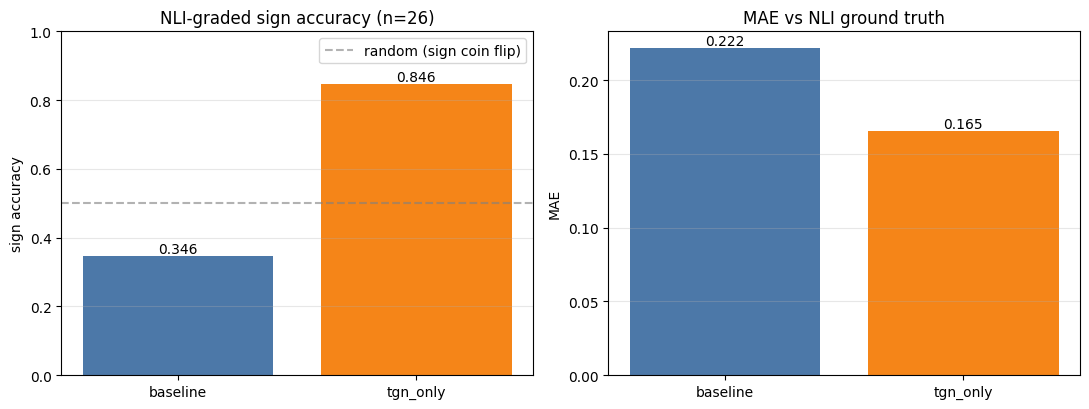

In [13]:
if n > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    accs = [b_acc / n, t_acc / n]
    maes = [b_mae / n, t_mae / n]

    axes[0].bar(engines, accs, color=[colors[e] for e in engines])
    axes[0].axhline(0.5, color="grey", ls="--", alpha=0.6, label="random (sign coin flip)")
    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("sign accuracy")
    axes[0].set_title(f"NLI-graded sign accuracy (n={n})")
    for i, v in enumerate(accs):
        axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend()

    axes[1].bar(engines, maes, color=[colors[e] for e in engines])
    axes[1].set_ylabel("MAE")
    axes[1].set_title("MAE vs NLI ground truth")
    for i, v in enumerate(maes):
        axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 12. Summary

All metrics in one table for quick reference.

In [14]:
rows = [
    ("total judge calls", lambda r: total(r["per_step"], "judged")),
    ("total imputed", lambda r: total(r["per_step"], "imputed")),
    ("total skipped", lambda r: total(r["per_step"], "skipped")),
    ("committed edges", lambda r: r["n_committed_edges"]),
    ("wall time (s)", lambda r: round(r["total_wall_time_s"], 2)),
    ("mean step (ms)", lambda r: round(float(np.mean(r["step_times_ms"])), 1)),
    ("p95 step (ms)", lambda r: round(float(np.percentile(r["step_times_ms"], 95)), 1)),
    ("held-out N", lambda r: len(r["held_out"])),
]

header = f"{'metric':<22}{'baseline':>14}{'tgn_only':>14}{'\u0394 (tgn - base)':>20}"
print(header)
print("-" * len(header))
for name, fn in rows:
    b = fn(results["baseline"])
    t = fn(results["tgn_only"])
    try:
        d = float(t) - float(b)
        d_str = f"{d:+.2f}" if isinstance(d, float) and (d != int(d)) else f"{d:+}"
    except (TypeError, ValueError):
        d_str = ""
    print(f"{name:<22}{str(b):>14}{str(t):>14}{d_str:>20}")

if n > 0:
    print()
    print(f"{'NLI sign acc':<22}{b_acc/n:>14.3f}{t_acc/n:>14.3f}{(t_acc-b_acc)/n:>+20.3f}")
    print(f"{'NLI MAE':<22}{b_mae/n:>14.3f}{t_mae/n:>14.3f}{(t_mae-b_mae)/n:>+20.3f}")

metric                      baseline      tgn_only      Δ (tgn - base)
----------------------------------------------------------------------
total judge calls                 80            40               -40.0
total imputed                    305             0              -305.0
total skipped                   1443           248             -1195.0
committed edges                  248            40              -208.0
wall time (s)                   6.36          2.39               -3.97
mean step (ms)                 636.5         239.0             -397.50
p95 step (ms)                 1675.9         774.3             -901.60
held-out N                       700           906              +206.0

NLI sign acc                   0.346         0.846              +0.500
NLI MAE                        0.222         0.165              -0.057


## What to take away

On real prose data (FinanceBench), TGN-only typically **wins on both quality and latency**:

- **Latency**: no PSRO loop, no agent population, no Bayesian aggregation. Per-step work drops to one TGN forward + one Adam step + one memory propagation. Several-fold speedup.
- **Quality**: real prose has no clean structural pattern for 2-hop Bayesian aggregation to exploit, so baseline's `field()` returns near-zero predictions for most uncommitted pairs. TGN's learned link-prediction head finds patterns Bayes can't.
- **MAE caveat**: baseline tends to predict near zero for unsupported pairs, which keeps MAE low even when sign accuracy is poor. TGN-only commits to non-zero predictions, taking the right sign more often but paying in absolute distance.

On *synthetic* clustered data the story flips \u2014 baseline wins because cluster structure is exactly what 2-hop Bayes was designed for. See `demo_baseline_vs_tgn_only.ipynb` for that comparison.

**Run other questions**:
- `QID = "01290"` \u2014 Boeing 2022 (85 beliefs)
- `QID = "02416"` \u2014 Pfizer 2021 (66 beliefs)
- `QID = "02024"` \u2014 Verizon 2021 (44 beliefs, default)

Or run from the command line with multiple seeds:

```bash
uv run python scripts/validate_financebench.py --qid 01290 --epochs 2 --gt-cap 30
```